In [1]:
import zipfile
import pandas as pd
import os
import seaborn as sns
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

In [2]:
zip_file_path = "metropt+3+dataset.zip"
extract_path = 'data'  # dossier local

# Crée le dossier s'il n'existe pas
os.makedirs(extract_path, exist_ok=True)

# Extraction
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"'{zip_file_path}' unzipped to '{extract_path}'.")

try:
    csv_path = os.path.join(extract_path, 'MetroPT3(AirCompressor).csv')
    df = pd.read_csv(csv_path)

    print("\nDataFrame 'df' loaded successfully.")
    print("\nFirst 5 rows of the DataFrame:")
    print(df.head())

    print("\nDataFrame Information:")
    df.info()

except FileNotFoundError:
    print("FileNotFoundError: CSV file not found.")
except Exception as e:
    print(f"An error occurred: {e}")

'metropt+3+dataset.zip' unzipped to 'data'.

DataFrame 'df' loaded successfully.

First 5 rows of the DataFrame:
   Unnamed: 0            timestamp    TP2    TP3     H1  DV_pressure  \
0           0  2020-02-01 00:00:00 -0.012  9.358  9.340       -0.024   
1          10  2020-02-01 00:00:10 -0.014  9.348  9.332       -0.022   
2          20  2020-02-01 00:00:19 -0.012  9.338  9.322       -0.022   
3          30  2020-02-01 00:00:29 -0.012  9.328  9.312       -0.022   
4          40  2020-02-01 00:00:39 -0.012  9.318  9.302       -0.022   

   Reservoirs  Oil_temperature  Motor_current  COMP  DV_eletric  Towers  MPG  \
0       9.358           53.600         0.0400   1.0         0.0     1.0  1.0   
1       9.348           53.675         0.0400   1.0         0.0     1.0  1.0   
2       9.338           53.600         0.0425   1.0         0.0     1.0  1.0   
3       9.328           53.425         0.0400   1.0         0.0     1.0  1.0   
4       9.318           53.475         0.0400   1.0   

In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1516948 entries, 0 to 1516947
Data columns (total 17 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   Unnamed: 0       1516948 non-null  int64         
 1   timestamp        1516948 non-null  datetime64[ns]
 2   TP2              1516948 non-null  float64       
 3   TP3              1516948 non-null  float64       
 4   H1               1516948 non-null  float64       
 5   DV_pressure      1516948 non-null  float64       
 6   Reservoirs       1516948 non-null  float64       
 7   Oil_temperature  1516948 non-null  float64       
 8   Motor_current    1516948 non-null  float64       
 9   COMP             1516948 non-null  float64       
 10  DV_eletric       1516948 non-null  float64       
 11  Towers           1516948 non-null  float64       
 12  MPG              1516948 non-null  float64       
 13  LPS              1516948 non-null  float64       
 14  Pr

In [4]:
print(df.isnull().sum())

Unnamed: 0         0
timestamp          0
TP2                0
TP3                0
H1                 0
DV_pressure        0
Reservoirs         0
Oil_temperature    0
Motor_current      0
COMP               0
DV_eletric         0
Towers             0
MPG                0
LPS                0
Pressure_switch    0
Oil_level          0
Caudal_impulses    0
dtype: int64


## Exploration of potentially relevant columns

Before moving forward, we chose to keep some columns among others : `TP2`, `TP3`, `DV_pressure`, `Reservoirs`, `LPS`, `Pressure_switch`, and `Caudal_impulses`

The variables `TP2` and `TP3` measure the pressure at the compressor and at the pneumatic panel, respectively. Since air leaks primarily manifest as abnormal pressure drops or unstable pressure regulation, these two measurements are fundamental to detecting deviations in pressure generation and distribution across the system.

`DV_pressure` represents the pressure drop generated during air dryer tower discharge, with a zero value indicating that the compressor is operating under load. This variable is particularly informative because abnormal discharge patterns or prolonged load conditions may indicate compensatory behavior caused by a leak.

`Reservoirs` measures the downstream pressure of the air reservoirs, which should normally remain close to the pneumatic panel pressure (`TP3`). A persistent gap between these pressures or abnormal decay in reservoir pressure can signal leakage in the storage or distribution stage.

`LPS` (Low Pressure Switch) activates when pressure drops below 7 bar, providing a discrete indication of critical pressure loss. This makes it a highly relevant feature for identifying severe leakage events or sustained pressure degradation.

`Pressure_switch` detects discharge events in the air-drying towers. Abnormally frequent discharge cycles may reflect instability in pressure maintenance, potentially linked to air leaks.

Finally, `Caudal_impulses` counts airflow pulses corresponding to the absolute amount of air flowing from the Air Production Unit (APU) to the reservoirs. In the presence of a leak, the system may compensate by increasing airflow frequency or volume, creating inconsistencies between pressure stability and airflow rate. This makes the variable particularly valuable for detecting subtle leakage behavior.

Other variables such as `Motor_current`, `Oil_temperature`, `Oil_level`, `COMP`, `DV_electric`, `TOWERS`, and `MPG` are primarily related to the mechanical state, thermal condition, or control logic of the compressor. While they are important for diagnosing electrical faults, lubrication problems, overheating, or control failures, they are less directly linked to the physical manifestation of air leaks. 


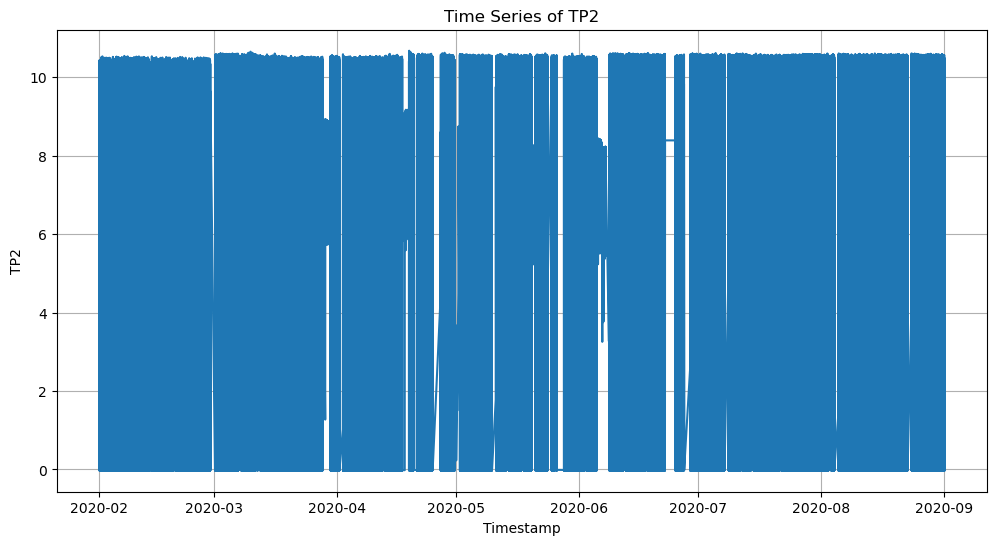

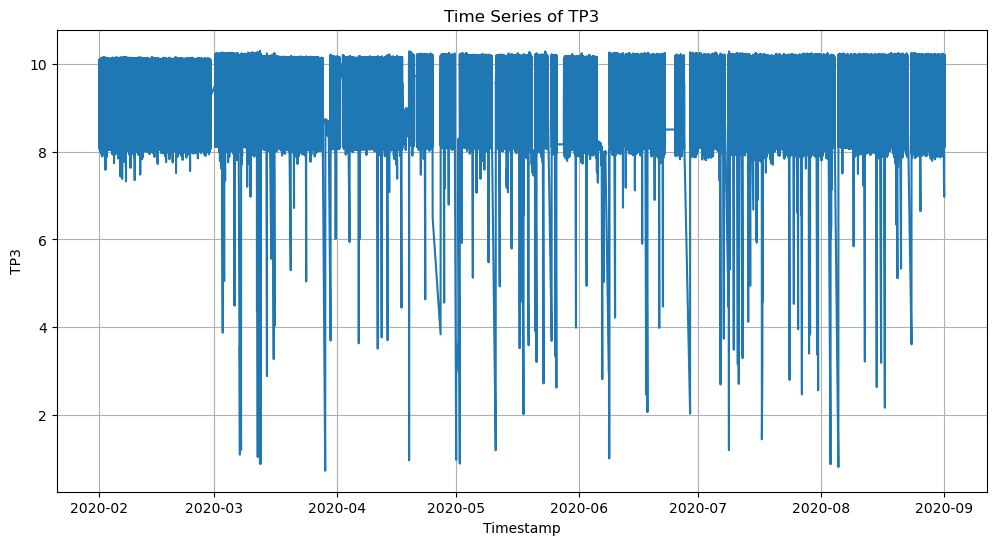

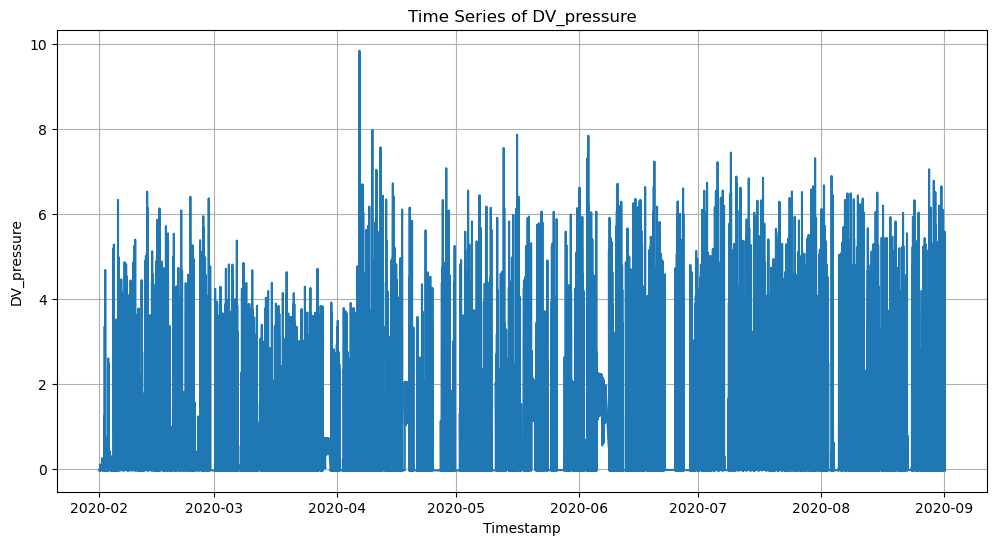

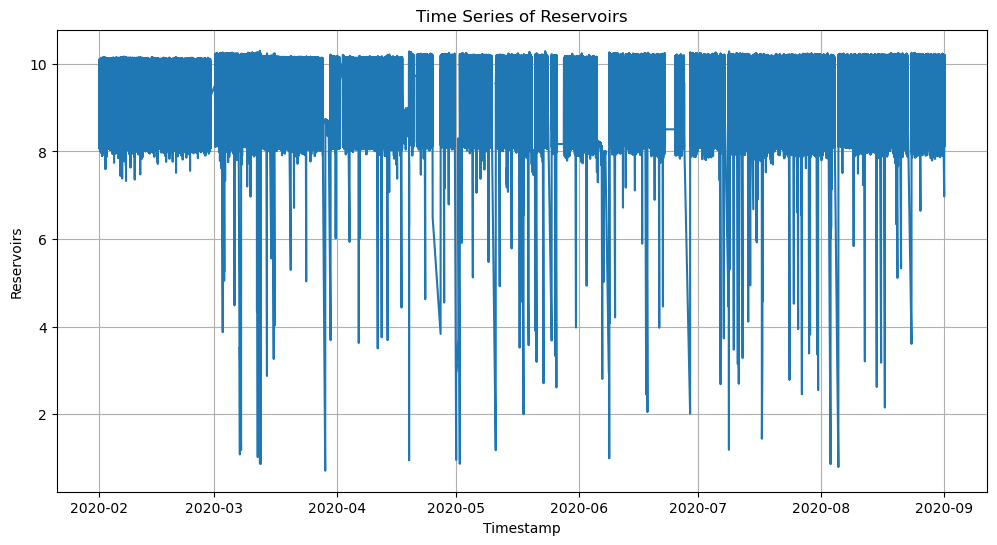

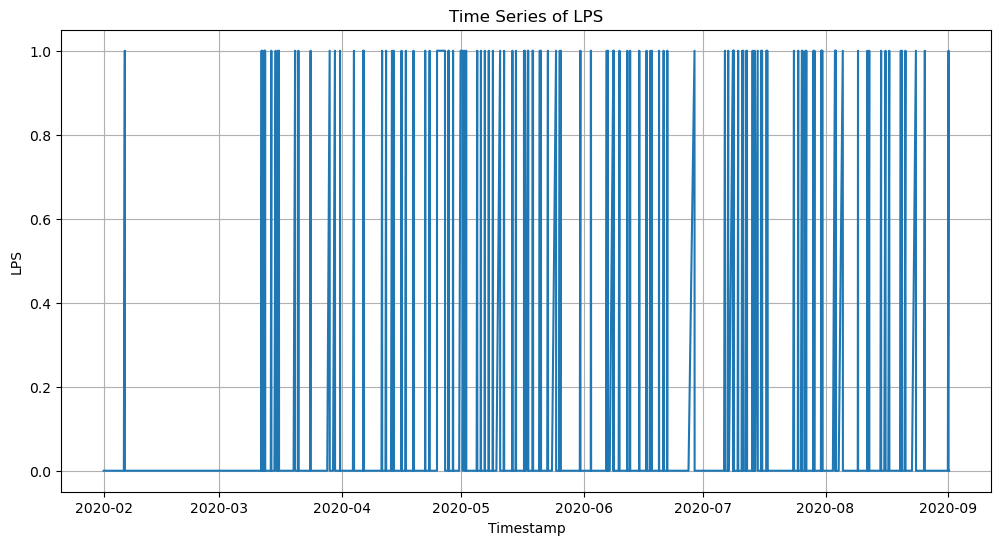

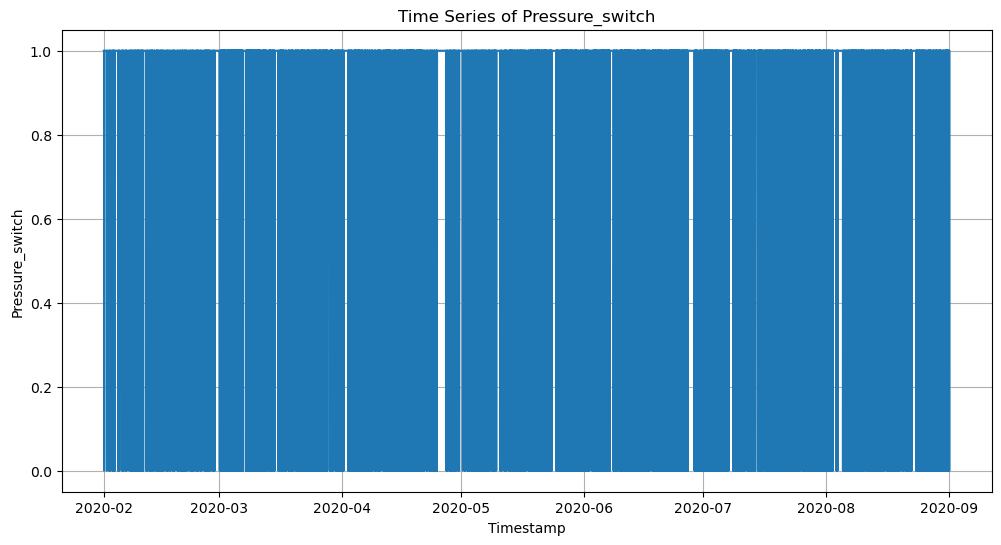

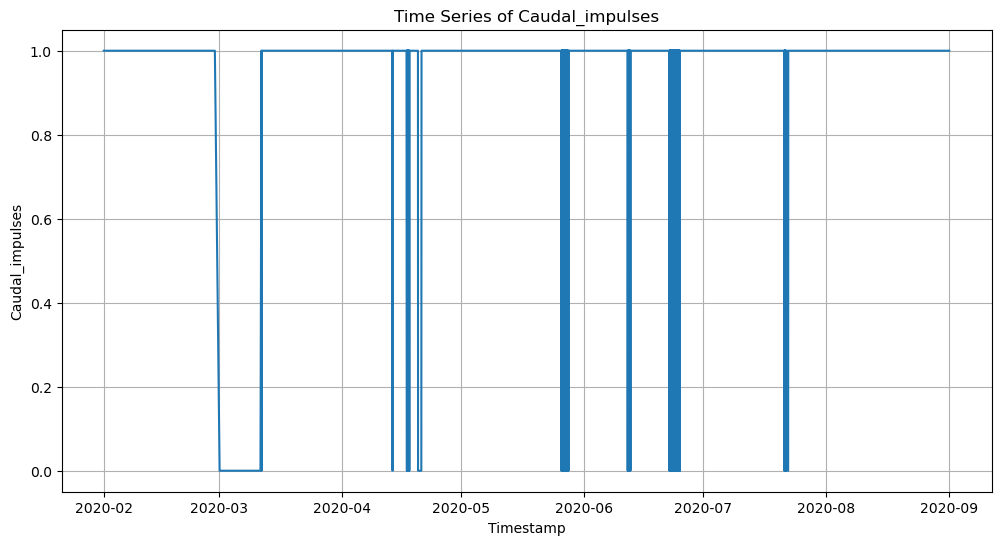

Time series plots generated for selected columns.


In [5]:
columns_to_plot = ['TP2', 'TP3', 'DV_pressure', 'Reservoirs', 'LPS', 'Pressure_switch', 'Caudal_impulses']

for column in columns_to_plot:
    plt.figure(figsize=(12, 6))
    plt.plot(df['timestamp'], df[column])
    plt.xlabel('Timestamp')
    plt.ylabel(column)
    plt.title(f'Time Series of {column}')
    plt.grid(True)
    plt.show()
print("Time series plots generated for selected columns.")

The time series plots show strong periodic behavior and operational cycles, particularly in pressure-related variables such as TP3 and Reservoirs. This indicates that the compressor operates in repetitive load/unload cycles.
However, no visually obvious large spikes or abrupt anomalies are clearly distinguishable, suggesting that potential air leaks may manifest as subtle distributional shifts rather than sharp outliers.

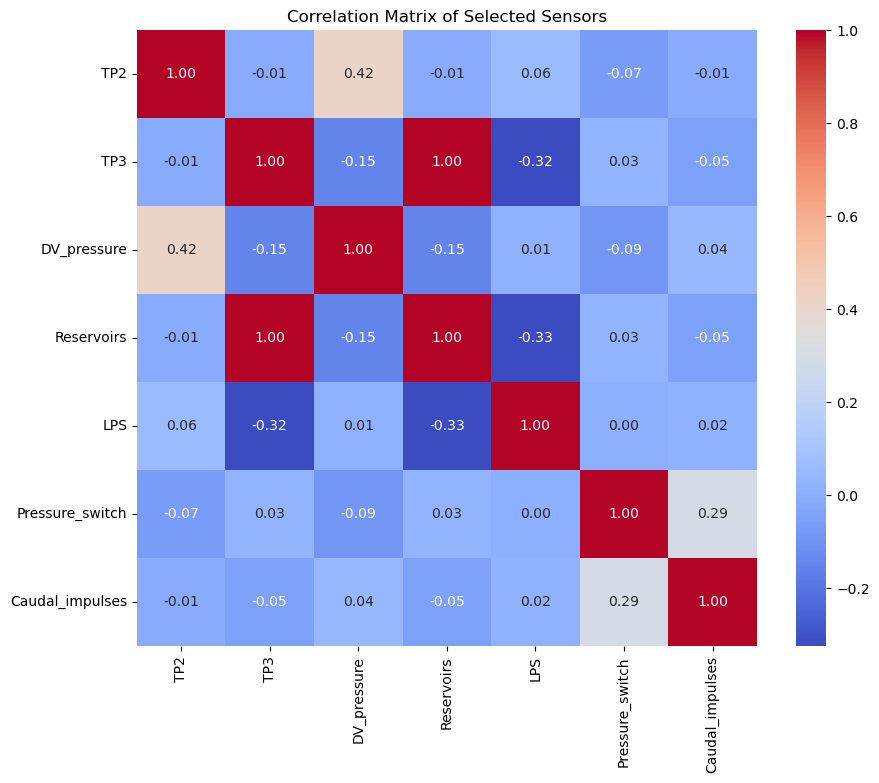

In [6]:
columns_for_correlation = ['TP2', 'TP3', 'DV_pressure', 'Reservoirs', 'LPS', 'Pressure_switch', 'Caudal_impulses']
correlation_matrix = df[columns_for_correlation].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Selected Sensors')
plt.show()

The correlation matrix shows strong positive correlations between `Reservoirs` and `TP3`, which is expected since reservoir pressure should follow pneumatic panel pressure.
This redundancy suggests that some variables may not provide independent anomaly information. Highly correlated features can reduce the effectiveness of Isolation Forest, as the model may focus on dominant variance directions rather than subtle deviations. 
We chose to remove `Reservoirs` from our analysis.

In [7]:
columns_to_engineer = ['TP2', 'DV_pressure', 'LPS', 'Pressure_switch', 'Caudal_impulses', 'TP3']

df_features = pd.DataFrame()

window_size = 50

for col in columns_to_engineer:
    # Rolling standard deviation
    df_features[f'{col}_rolling_std'] = df[col].rolling(window=window_size).std()

    # Rolling median
    rolling_median = df[col].rolling(window=window_size).median()

    # Rolling residual
    df_features[f'{col}_rolling_residual'] = df[col] - rolling_median

# Drop rows with NaN values resulting from rolling calculations
df_features.dropna(inplace=True)

print("Engineered features DataFrame created and NaN values handled.")
print("First 5 rows of df_features:")
print(df_features.head())
print("df_features Info:")
df_features.info()

Engineered features DataFrame created and NaN values handled.
First 5 rows of df_features:
    TP2_rolling_std  TP2_rolling_residual  DV_pressure_rolling_std  \
49         0.001007                -0.002                 0.000997   
50         0.001009                -0.002                 0.000990   
51         0.001007                 0.000                 0.000997   
52         0.001009                -0.002                 0.000997   
53         0.001010                -0.001                 0.000997   

    DV_pressure_rolling_residual  LPS_rolling_std  LPS_rolling_residual  \
49                        -0.002              0.0                   0.0   
50                         0.000              0.0                   0.0   
51                        -0.002              0.0                   0.0   
52                         0.000              0.0                   0.0   
53                         0.000              0.0                   0.0   

    Pressure_switch_rolling_std  Pres

Rolling standard deviation captures local variability, which may increase in the presence of unstable pressure regulation.
Rolling residuals capture deviations from short-term median behavior, potentially highlighting slow drifts associated with air leaks.
However, the chosen window size (50 samples) may smooth out slow degradation patterns, limiting sensitivity to progressive leaks.

## Train Isolation Forest on Data Before April 1st and Set Threshold

Thanks to the file Data Description_metro, we know when the detected air leaks took place : we know that there are no anomalies detected before 4/18/2020 0:00. 

We chose to split the engineered features DataFrame into a training set containing all data points with timestamps before April 1st, and a prediction set containing the remaining data.

We chose to end the training set more than two weeks before the first actual anomaly in order to avoid data leakage (temporal leakage more precisely)

In [8]:
df_merged_features = df.loc[df_features.index].copy()
df_merged_features = pd.concat([df_merged_features, df_features], axis=1)

print("Merged DataFrame 'df_merged_features' created.")
print("First 5 rows of df_merged_features:")
print(df_merged_features.head())
print("df_merged_features Info:")
df_merged_features.info()

Merged DataFrame 'df_merged_features' created.
First 5 rows of df_merged_features:
    Unnamed: 0           timestamp    TP2    TP3     H1  DV_pressure  \
49         490 2020-02-01 00:08:06 -0.014  8.862  8.850       -0.024   
50         500 2020-02-01 00:08:15 -0.014  8.854  8.840       -0.022   
51         510 2020-02-01 00:08:25 -0.012  8.846  8.830       -0.024   
52         520 2020-02-01 00:08:35 -0.014  8.836  8.820       -0.022   
53         530 2020-02-01 00:08:45 -0.014  8.826  8.812       -0.022   

    Reservoirs  Oil_temperature  Motor_current  COMP  ...  \
49       8.866           52.650         0.0400   1.0  ...   
50       8.856           52.725         0.0400   1.0  ...   
51       8.848           52.575         0.0400   1.0  ...   
52       8.838           52.600         0.0425   1.0  ...   
53       8.828           52.500         0.0400   1.0  ...   

    DV_pressure_rolling_std  DV_pressure_rolling_residual  LPS_rolling_std  \
49                 0.000997            

In [9]:
# Split data into training and prediction sets
df_train = df_merged_features[df_merged_features['timestamp'] < '2020-04-01'].copy()
df_predict = df_merged_features[df_merged_features['timestamp'] >= '2020-04-01'].copy()

# Define the feature columns for the Isolation Forest model (excluding 'timestamp', 'anomaly_score', 'anomaly_label', and original columns)
feature_columns = [col for col in df_features.columns if col not in ['anomaly_score', 'anomaly_label']]

X_train = df_train[feature_columns]

model = IsolationForest(contamination=0.01, random_state=42, n_estimators=100)

model.fit(X_train)

train_anomaly_scores = model.decision_function(X_train)

anomaly_threshold = max(train_anomaly_scores) * 1.25

print(f"Data split into training (before 2020-04-01) and prediction sets.")
print(f"Training data shape: {df_train.shape}")
print(f"Prediction data shape: {df_predict.shape}")
print(f"Isolation Forest model trained on training data.")
print(f"Calculated anomaly threshold: {anomaly_threshold}")

Data split into training (before 2020-04-01) and prediction sets.
Training data shape: (445249, 29)
Prediction data shape: (1071650, 29)
Isolation Forest model trained on training data.
Calculated anomaly threshold: 0.3863061345836671


The training set contains approximately 29% of the total dataset and represents early operational behavior.
However, since no explicit buffer zone was introduced before the anomaly period, the training data may contain pre-failure behavior, potentially biasing the model’s understanding of “normal” conditions.

The Isolation Forest was trained solely on pre-April data to model normal compressor behavior.
The anomaly threshold was derived from the model’s internal scoring mechanism. However, since Isolation Forest assumes anomalies are rare and clearly separable, its performance strongly depends on the contamination parameter and the representativeness of the training data.

If subtle degradation patterns are present in the training data, the model may fail to isolate them effectively.

Total number of anomalies detected in the full dataset: 24035
Number of anomalies for TP2: 24035


C:\Users\natha\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


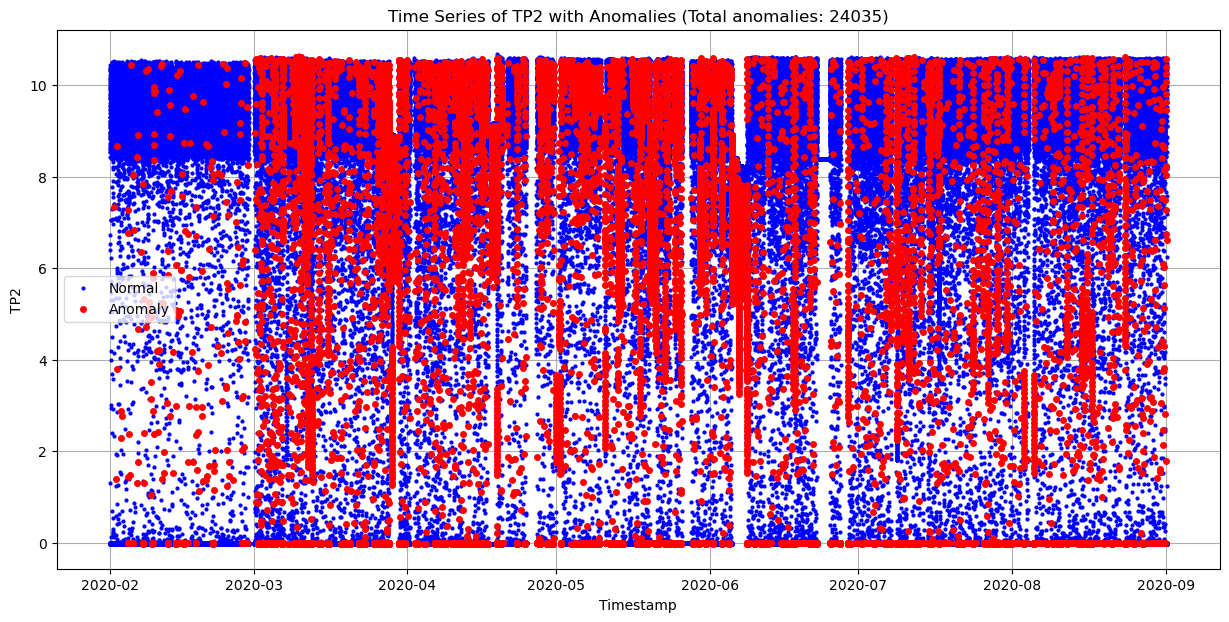

Number of anomalies for DV_pressure: 24035


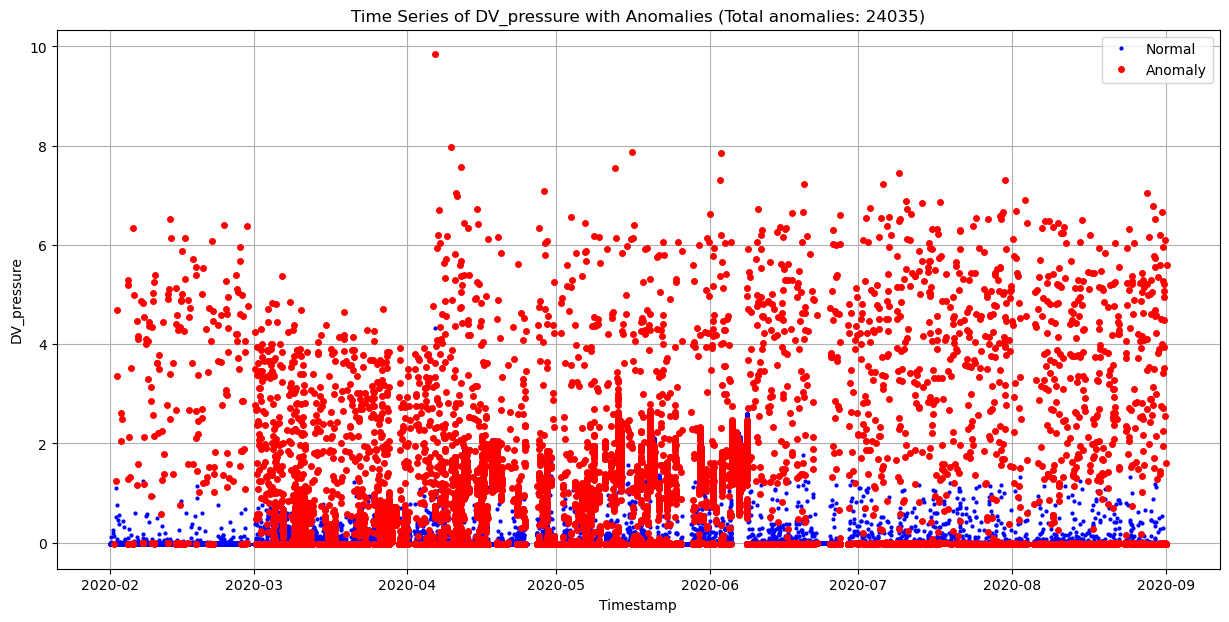

Number of anomalies for LPS: 24035


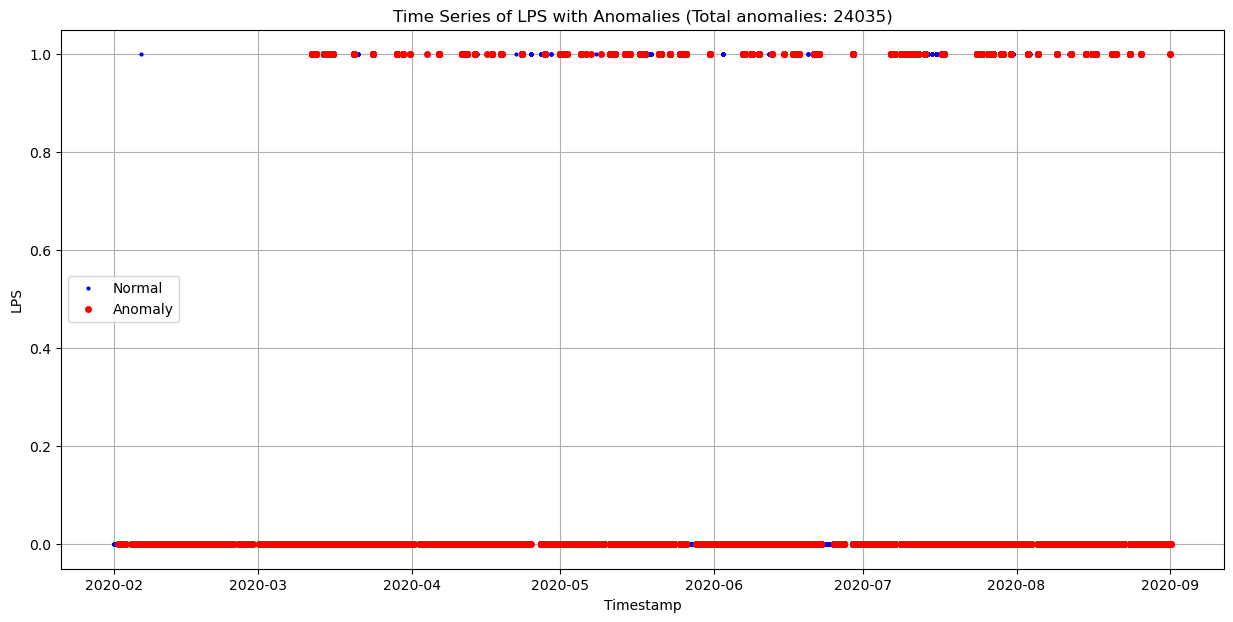

Number of anomalies for Pressure_switch: 24035


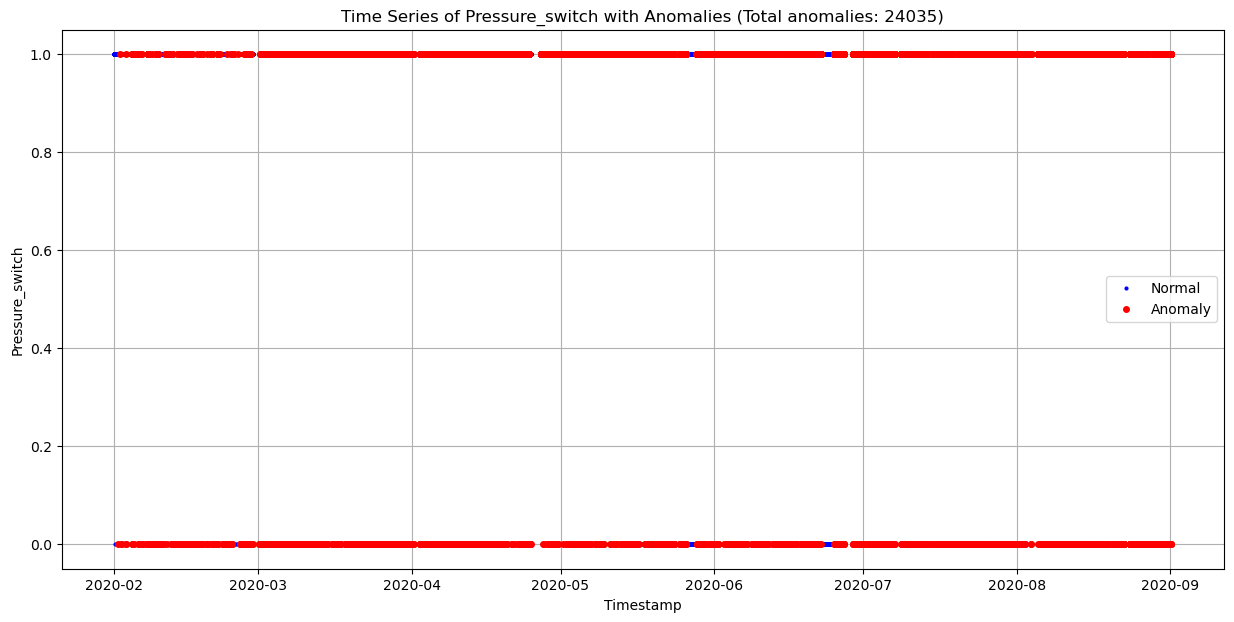

Number of anomalies for Caudal_impulses: 24035


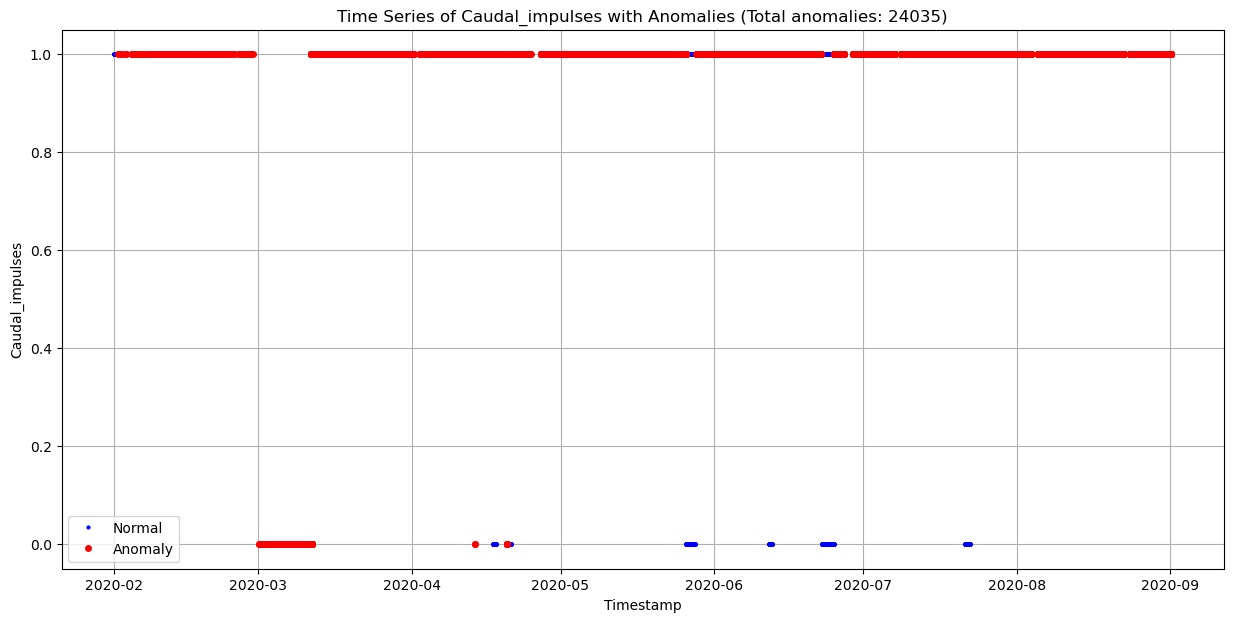

Number of anomalies for TP3: 24035


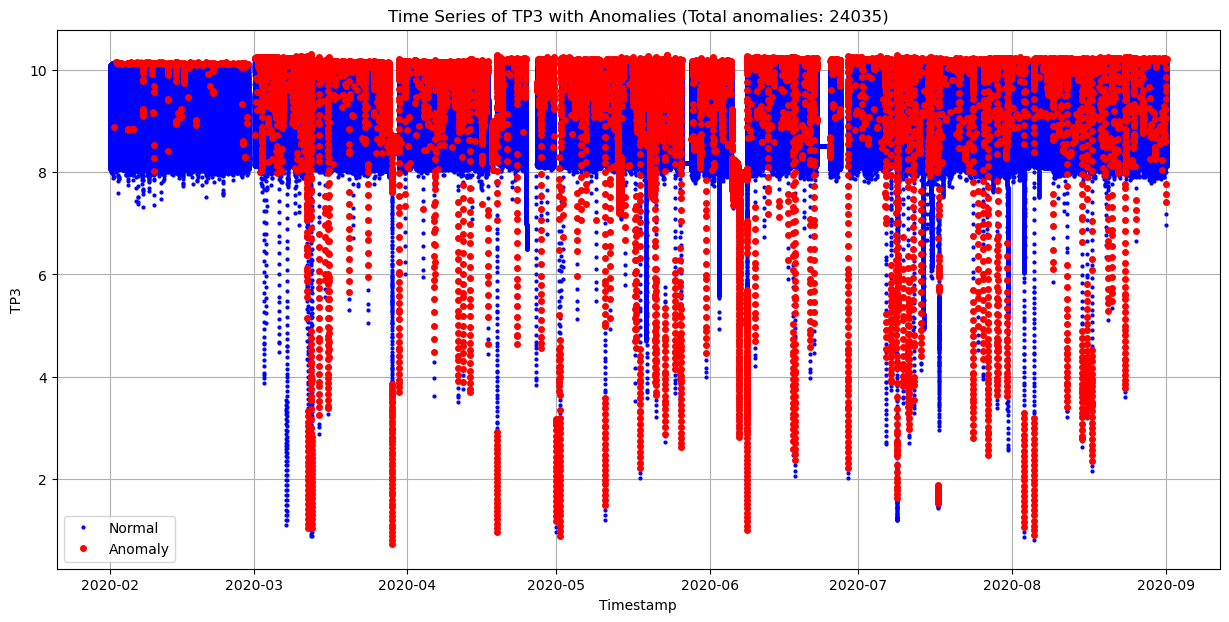

Anomaly visualization plots generated for selected columns using the model's internal threshold.


In [10]:
# Predict anomaly labels for the entire df_merged_features using the trained model
# IsolationForest's predict method returns -1 for outliers and 1 for inliers.
full_anomaly_labels = model.predict(df_merged_features[feature_columns])

# Store these predicted anomaly labels in a new column named 'is_anomaly'
# Convert -1 (anomaly) to 1, and 1 (normal) to 0 for consistent plotting logic.
df_merged_features['is_anomaly'] = (full_anomaly_labels == -1).astype(int)

# Identify anomalies (where 'is_anomaly' is 1)
num_total_anomalies = df_merged_features['is_anomaly'].sum()
print(f"Total number of anomalies detected in the full dataset: {num_total_anomalies}")

# Define a list of original columns to visualize
columns_to_visualize = ['TP2', 'DV_pressure', 'LPS', 'Pressure_switch', 'Caudal_impulses', 'TP3']

for col in columns_to_visualize:

    # Count anomalies for this column (points that will appear in red)
    num_anomalies_col = df_merged_features[df_merged_features['is_anomaly'] == 1][col].count()
    print(f"Number of anomalies for {col}: {num_anomalies_col}")

    plt.figure(figsize=(15, 7))

    # Plot normal points
    plt.plot(df_merged_features[df_merged_features['is_anomaly'] == 0]['timestamp'],
             df_merged_features[df_merged_features['is_anomaly'] == 0][col],
             'o', markersize=2, color='blue', label='Normal')

    # Plot anomalous points
    plt.plot(df_merged_features[df_merged_features['is_anomaly'] == 1]['timestamp'],
             df_merged_features[df_merged_features['is_anomaly'] == 1][col],
             'o', markersize=4, color='red', label='Anomaly')

    plt.title(f'Time Series of {col} with Anomalies (Total anomalies: {num_anomalies_col})')
    plt.xlabel('Timestamp')
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)
    plt.show()

print("Anomaly visualization plots generated for selected columns using the model's internal threshold.")

The model detected 24035 anomalies across the full dataset, representing a very small fraction of observations (~0.16%).
This suggests that the model is highly conservative and may only detect extreme deviations rather than gradual air leak patterns.

The anomaly visualization shows that detected points are sparsely distributed and often correspond to local fluctuations rather than sustained pressure degradation.
The model does not appear to capture progressive drifts in pressure levels, which are characteristic of air leaks.
Instead, it primarily detects isolated short-term variations.

## Conclusion

The Isolation Forest model demonstrates limited effectiveness for detecting air leaks in this dataset.
While it successfully identifies a small number of statistical outliers, it fails to capture the progressive and dynamic nature of air leakage phenomena.
Air leaks typically manifest as slow pressure drifts and increased cycling frequency rather than abrupt, isolated anomalies.

Additionally:
- Strong feature correlation may reduce anomaly separability.
- The absence of a temporal buffer before anomalies introduces potential bias.
- Isolation Forest is primarily designed for **point anomaly detection** rather than temporal degradation modeling.
- Therefore, the model appears insufficient for reliable predictive maintenance in this context.

More appropriate approaches may include:
- LSTM-based sequence models
- Autoencoder architectures
- Change-point detection methods
- Drift detection algorithms
- Supervised classification if failure labels are available

In summary, the current approach detects statistical outliers but **does not effectively capture the underlying failure mechanism of air leaks**..

In [11]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

# Features utilisées pour le modèle
feature_cols = df_features.columns

X_train = df_train[feature_cols]
X_all = df_merged_features[feature_cols]

# Standardisation (important pour SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_all_scaled = scaler.transform(X_all)

# Modèle One-Class SVM
svm_model = OneClassSVM(
    kernel='rbf',
    gamma='scale',
    nu=0.01   # proportion approximative d'anomalies attendues
)

# Entraînement
svm_model.fit(X_train_scaled)

# Prédiction
svm_pred = svm_model.predict(X_all_scaled)

# Conversion: -1 = anomalie, 1 = normal
df_merged_features['anomaly_svm'] = svm_pred

print("Nombre d'anomalies détectées :", (svm_pred == -1).sum())

Nombre d'anomalies détectées : 79158


In [12]:
from sklearn.covariance import EllipticEnvelope

# Features
X_train = df_train[feature_cols]
X_all = df_merged_features[feature_cols]

# Standardisation recommandée
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_all_scaled = scaler.transform(X_all)

# Modèle Elliptic Envelope
elliptic_model = EllipticEnvelope(
    contamination=0.01,   # proportion estimée d'anomalies
    random_state=42
)

# Entraînement
elliptic_model.fit(X_train_scaled)

# Prédiction
elliptic_pred = elliptic_model.predict(X_all_scaled)

df_merged_features['anomaly_elliptic'] = elliptic_pred

print("Nombre d'anomalies détectées :", (elliptic_pred == -1).sum())

Nombre d'anomalies détectées : 23032


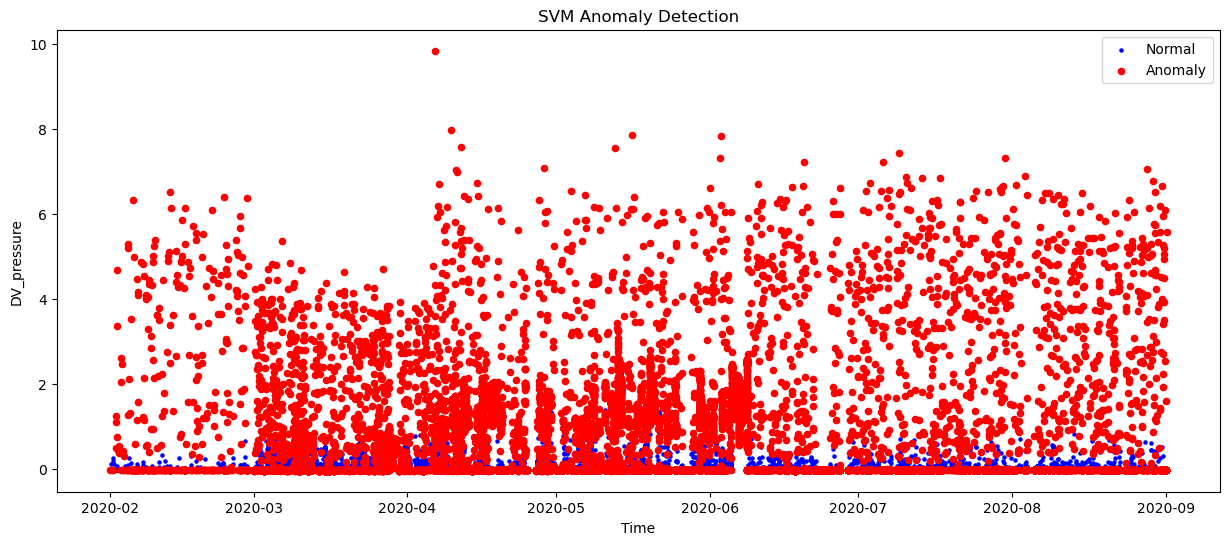

In [13]:
plt.figure(figsize=(15,6))

normal = df_merged_features[df_merged_features['anomaly_svm'] == 1]
anomaly = df_merged_features[df_merged_features['anomaly_svm'] == -1]

plt.scatter(normal['timestamp'],
            normal['DV_pressure'],
            color='blue',
            s=5,
            label='Normal')

plt.scatter(anomaly['timestamp'],
            anomaly['DV_pressure'],
            color='red',
            s=20,
            label='Anomaly')

plt.xlabel("Time")
plt.ylabel("DV_pressure")
plt.title("SVM Anomaly Detection")
plt.legend()
plt.show()

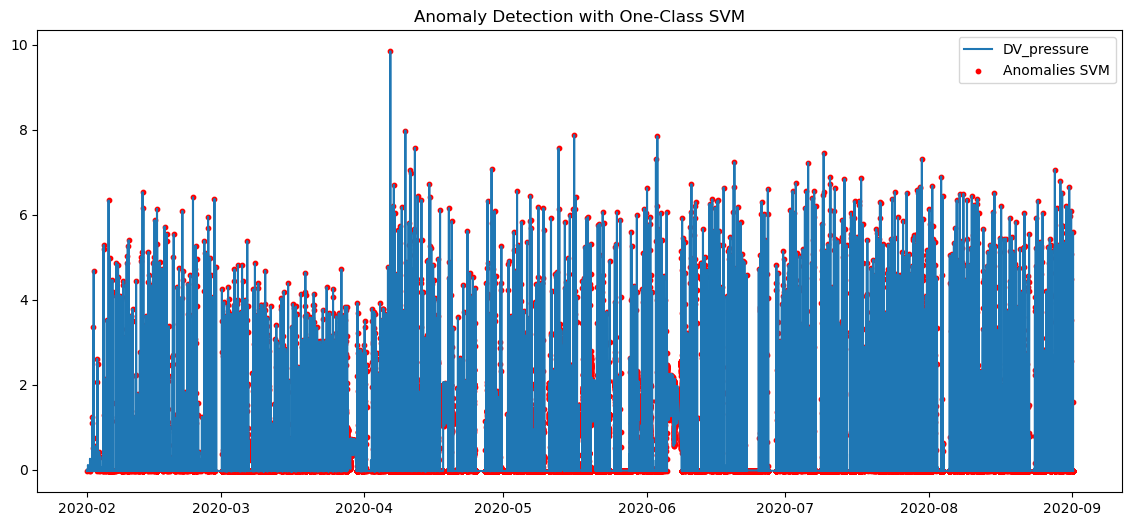

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df_merged_features['timestamp'],
         df_merged_features['DV_pressure'],
         label='DV_pressure')

anomalies = df_merged_features[df_merged_features['anomaly_svm'] == -1]

plt.scatter(anomalies['timestamp'],
            anomalies['DV_pressure'],
            color='red',
            label='Anomalies SVM',
            s=10)

plt.legend()
plt.title("Anomaly Detection with One-Class SVM")
plt.show()

In [15]:
print("IsolationForest:", (df_merged_features['is_anomaly'] == 1).sum())
print("OneClassSVM:", (df_merged_features['anomaly_svm'] == -1).sum())
print("EllipticEnvelope:", (df_merged_features['anomaly_elliptic'] == -1).sum())

IsolationForest: 24035
OneClassSVM: 79158
EllipticEnvelope: 23032


In [16]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

df_merged_features['timestamp'] = pd.to_datetime(df_merged_features['timestamp'])
df_merged_features['real_failure'] = 0

failure_periods = [
    ("2020-04-18 00:00:00", "2020-04-18 23:59:00"),
    ("2020-05-29 23:30:00", "2020-05-30 06:00:00"),
    ("2020-06-05 10:00:00", "2020-06-07 14:30:00"),
    ("2020-07-15 14:30:00", "2020-07-15 19:00:00")
]

for start, end in failure_periods:
    mask = (df_merged_features['timestamp'] >= start) & (df_merged_features['timestamp'] <= end)
    df_merged_features.loc[mask, 'real_failure'] = 1

y_true = df_merged_features['real_failure']

models_mapping = {
    "Isolation Forest": df_merged_features['is_anomaly'],
    "Elliptic Envelope": df_merged_features['anomaly_elliptic'].map({-1: 1, 1: 0}),
    "One-Class SVM": df_merged_features['anomaly_svm'].map({-1: 1, 1: 0})
}

results = []
for name, y_pred in models_mapping.items():
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    results.append({
        "Model": name,
        "TP": tp,
        "FP": fp,
        "Precision": report['1']['precision'],
        "Recall": report['1']['recall'],
        "F1-Score": report['1']['f1-score']
    })

df_performance = pd.DataFrame(results)
display(df_performance)

,Model,TP,FP,Precision,Recall,F1-Score
0,Isolation Forest,5838,18197,0.242896,0.194899,0.216266
1,Elliptic Envelope,8,23024,0.000347,0.000267,0.000302
2,One-Class SVM,3254,75904,0.041108,0.108633,0.059645


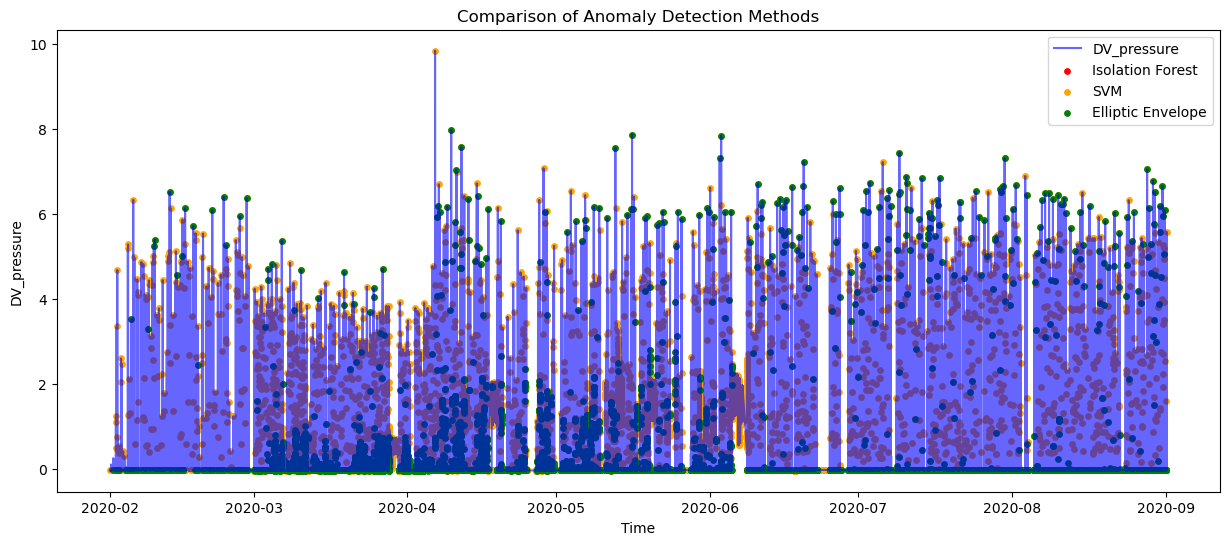

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

# Série normale
plt.plot(df_merged_features['timestamp'],
         df_merged_features['DV_pressure'],
         color='blue',
         alpha=0.6,
         label='DV_pressure')

# Isolation Forest
if 'is_anomaly' in df_merged_features.columns:
    iso = df_merged_features[df_merged_features['is_anomaly'] == -1]
    plt.scatter(iso['timestamp'],
                iso['DV_pressure'],
                color='red',
                s=15,
                label='Isolation Forest')

# SVM
svm = df_merged_features[df_merged_features['anomaly_svm'] == -1]
plt.scatter(svm['timestamp'],
            svm['DV_pressure'],
            color='orange',
            s=15,
            label='SVM')

# Elliptic Envelope
ell = df_merged_features[df_merged_features['anomaly_elliptic'] == -1]
plt.scatter(ell['timestamp'],
            ell['DV_pressure'],
            color='green',
            s=15,
            label='Elliptic Envelope')

plt.xlabel("Time")
plt.ylabel("DV_pressure")
plt.title("Comparison of Anomaly Detection Methods")
plt.legend()
plt.show()

In [20]:
features = feature_columns

# global z-scores
z_scores = (df_merged_features[features] - df_merged_features[features].mean()) / df_merged_features[features].std()

z_scores_abs = z_scores.abs()

In [21]:
def explain_anomalies(df, anomaly_col, z_scores_abs, model_name):

    anomalies = df[df[anomaly_col] == 1].copy()

    # feature the most reseponsible
    anomalies['main_cause'] = z_scores_abs.loc[anomalies.index].idxmax(axis=1)

    # contribution
    anomalies['contribution_score'] = z_scores_abs.loc[anomalies.index].max(axis=1)

    anomalies['model'] = model_name

    return anomalies[['timestamp','model','main_cause','contribution_score']]

In [23]:
results_if = explain_anomalies(
    df_merged_features,
    'is_anomaly',
    z_scores_abs,
    'IsolationForest'
)

results_svm = explain_anomalies(
    df_merged_features,
    'anomaly_svm',
    z_scores_abs,
    'OneClassSVM'
)

results_ee = explain_anomalies(
    df_merged_features,
    'anomaly_elliptic',
    z_scores_abs,
    'EllipticEnvelope'
)

In [24]:
all_results = pd.concat([
    results_if,
    results_svm,
    results_ee
])

print(all_results.head())

                timestamp            model                        main_cause  \
6755  2020-02-01 18:40:55  IsolationForest  Pressure_switch_rolling_residual   
7426  2020-02-02 05:21:04  IsolationForest      DV_pressure_rolling_residual   
8585  2020-02-02 08:36:34  IsolationForest      DV_pressure_rolling_residual   
9781  2020-02-02 11:54:08  IsolationForest      DV_pressure_rolling_residual   
16383 2020-02-03 06:04:48  IsolationForest      DV_pressure_rolling_residual   

       contribution_score  
6755            10.759846  
7426             8.107420  
8585            21.618500  
9781            30.101309  
16383           16.807737  


In [25]:
cause_summary = all_results.groupby(['model','main_cause']).size().reset_index(name='count')

print(cause_summary)

               model                        main_cause   count
0   EllipticEnvelope  Caudal_impulses_rolling_residual    8773
1   EllipticEnvelope       Caudal_impulses_rolling_std   34351
2   EllipticEnvelope      DV_pressure_rolling_residual   13745
3   EllipticEnvelope           DV_pressure_rolling_std   87967
4   EllipticEnvelope              LPS_rolling_residual    3200
5   EllipticEnvelope                   LPS_rolling_std    5259
6   EllipticEnvelope  Pressure_switch_rolling_residual    2986
7   EllipticEnvelope       Pressure_switch_rolling_std   29660
8   EllipticEnvelope              TP2_rolling_residual  120061
9   EllipticEnvelope                   TP2_rolling_std  768246
10  EllipticEnvelope              TP3_rolling_residual  199150
11  EllipticEnvelope                   TP3_rolling_std  220469
12   IsolationForest  Caudal_impulses_rolling_residual      74
13   IsolationForest       Caudal_impulses_rolling_std      42
14   IsolationForest      DV_pressure_rolling_residual 

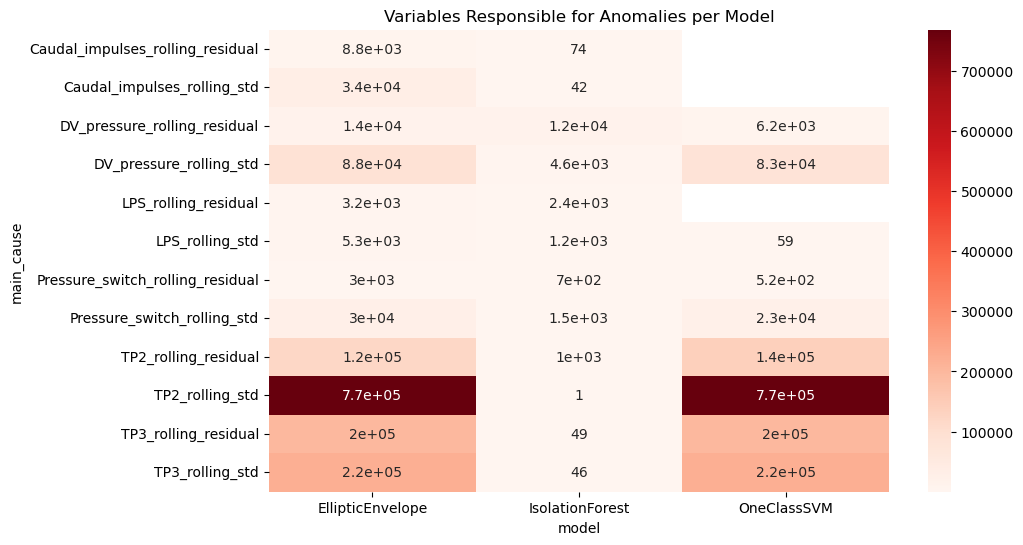

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = cause_summary.pivot(index="main_cause", columns="model", values="count")

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap="Reds")
plt.title("Variables Responsible for Anomalies per Model")
plt.show()

## Comparison of Anomaly Detection Methods

In this analysis, three unsupervised anomaly detection algorithms were applied to the MetroPT-3 industrial dataset: **Isolation Forest**, **One-Class SVM**, and **Elliptic Envelope**. These methods aim to identify unusual patterns in the sensor data that may indicate abnormal system behavior.

### Isolation Forest

Isolation Forest is an ensemble-based method specifically designed for anomaly detection. It works by randomly partitioning the data using decision trees. Since anomalies are rare and differ significantly from normal observations, they tend to be isolated with fewer splits in the trees. One advantage of this method is that it does not rely on assumptions about the underlying data distribution, making it well suited for complex industrial datasets.

### One-Class SVM

One-Class SVM is a kernel-based method that learns a boundary around the normal data points in a high-dimensional feature space. The model attempts to capture the region where most of the data lies and classifies points outside this region as anomalies. However, this method is sensitive to the choice of hyperparameters and feature scaling. If the boundary learned by the model is too restrictive, many observations may be incorrectly labeled as anomalous.

### Elliptic Envelope

Elliptic Envelope is a statistical approach based on robust covariance estimation. It assumes that normal observations follow a **multivariate Gaussian distribution** and fits an elliptical boundary around the central data points. Observations lying outside this ellipse are classified as anomalies. This method works well when the data approximately follow a Gaussian distribution but may perform poorly if the data are highly non-linear or multi-modal.

---

## Interpretation of the Results

The number of anomalies detected by each model is:

- **Isolation Forest:** 24,035 anomalies  
- **One-Class SVM:** 79,158 anomalies  
- **Elliptic Envelope:** 23,032 anomalies  

Isolation Forest and Elliptic Envelope detected a relatively similar number of anomalies, suggesting that both models identify a comparable subset of unusual observations in the dataset. In contrast, One-Class SVM detected a much larger number of anomalies, which likely indicates that the learned decision boundary is too restrictive for this dataset. As a result, many observations fall outside the estimated normal region. This behavior is a known limitation of One-Class SVM when the data distribution is complex or when hyperparameters are not perfectly tuned.

The analysis of the variables contributing to the anomalies provides additional insight into the behavior of the models. The results show that several features derived from **TP2 and TP3**, particularly `TP2_rolling_std`, `TP3_rolling_std`, and `TP3_rolling_residual`, frequently appear as the main contributors to anomalous behavior. These variables capture significant deviations in the system and therefore play an important role in identifying abnormal operating conditions.

Interestingly, Elliptic Envelope and One-Class SVM tend to concentrate anomaly detection on a small number of dominant variables, especially `TP2_rolling_std`. In contrast, Isolation Forest distributes anomaly contributions across a broader range of features. This suggests that Isolation Forest captures a wider variety of abnormal patterns in the data rather than focusing on a single highly variable signal.

Overall, **Isolation Forest appears to provide the most balanced and interpretable results for this dataset**. It detects a reasonable number of anomalies while also capturing diverse contributing variables. This makes it particularly suitable for industrial sensor data, where anomalies often result from complex interactions between multiple signals rather than a single isolated deviation.